# US Employment Economy (2016 – Present)

## Monthly Labor Market Analysis

## Description

This notebook provides a technical analysis of U.S. labor market dynamics using monthly nonfarm payroll data from the Federal Reserve Economic Data (FRED).

The analysis focuses on:

- Monthly changes in total nonfarm payrolls
- Three-month moving averages since 2016
- Structural shifts in employment behavior following recent events

This notebook examines **granular monthly variability** to identify transitions between:

- Stable expansion periods  
- Post-Covid recovery normalization  
- Late-cycle slowdown in 2024 
- Near-zero growth with increased volatility after 2024

Special attention is given from **2024 onward**, where labor market behavior transitioned into variance-dominated movement.

---

## Objectives

- Analyze U.S. payroll growth trends from 2016 to present  
- Compare pre-COVID baseline (2016–2019) with post-recovery behaviors (2021–present)  
- Identify the transition from steady growth to late-cycle labor market conditions  
- Detect regime shifts characterized by declining mean growth and increasing volatility  
- Contextualize employment behavior around political events  
- Provide a time-sensitive interpretation of labor market stability and ongoing risk

---

## Data Source

- Federal Reserve Economic Data (FRED)
  - PAYEMS: Total Nonfarm Payroll Employment  

Derived metrics:

- Monthly Job Growth = First difference of PAYEMS  
- 3-Month Moving Average = Rolling mean of monthly job growth  

All data is seasonally adjusted and reported in thousands of jobs.

In [11]:
# Install system dependencies
!pip install pandas-datareader


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


## Employment Trends (2016–2019)

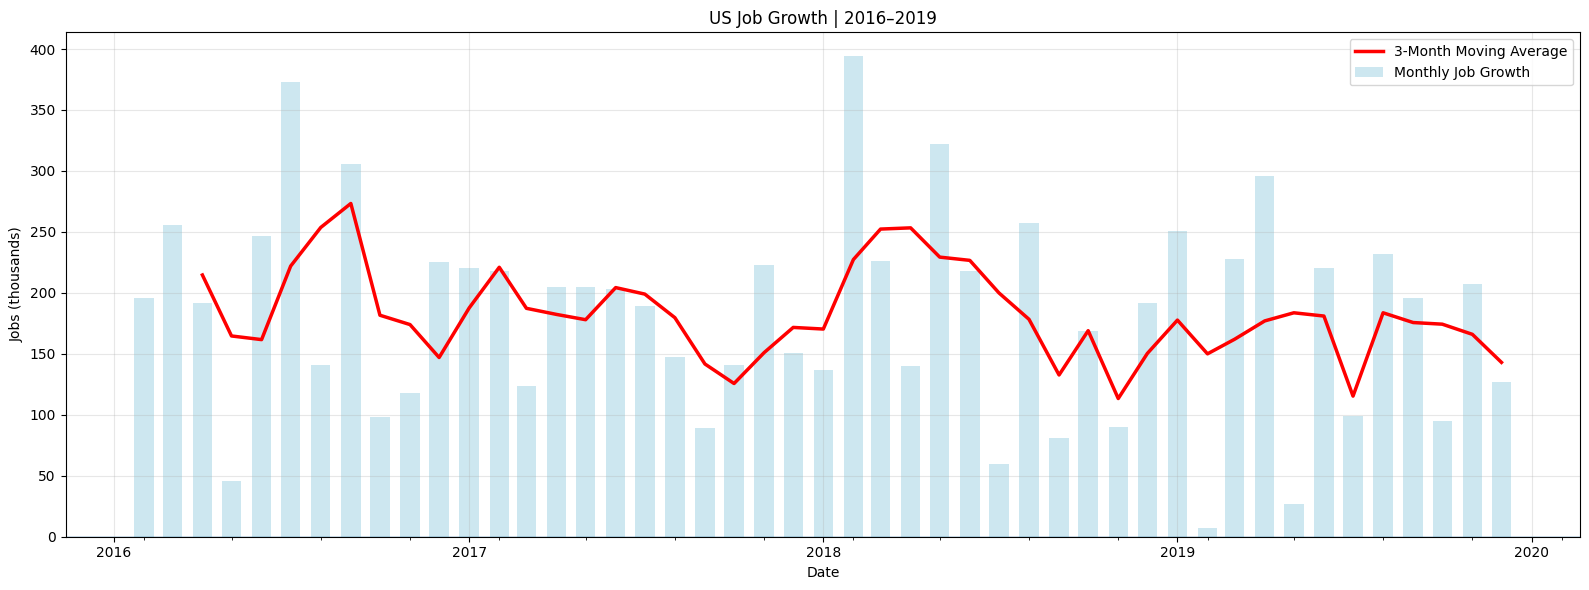

In [12]:
import pandas as pd
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# Date
start = datetime(2016, 1, 1)
end = datetime.now()

# Data source
df = web.DataReader("PAYEMS", "fred", start, end)

# Metrics
df["job_growth"] = df["PAYEMS"].diff()
df["ma_3"] = df["job_growth"].rolling(3).mean()

# 2016–2019 | Pre-COVID Pandemic
df_cov = df[(df.index >= "2016-01-01") & (df.index <= "2019-12-31")]

plt.figure(figsize=(16, 6))

plt.bar(df_cov.index, df_cov["job_growth"], color="lightblue",width=20, alpha=0.6, label="Monthly Job Growth")
plt.plot(df_cov.index, df_cov["ma_3"], color="red", linewidth=2.5, label="3-Month Moving Average")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))

plt.axhline(0, linewidth=1)
plt.grid(alpha=0.3)

plt.title("US Job Growth | 2016–2019")
plt.ylabel("Jobs (thousands)")
plt.xlabel("Date")
plt.legend()

plt.tight_layout()
plt.show()

## Post-Recovery Dynamics (2021–Present)

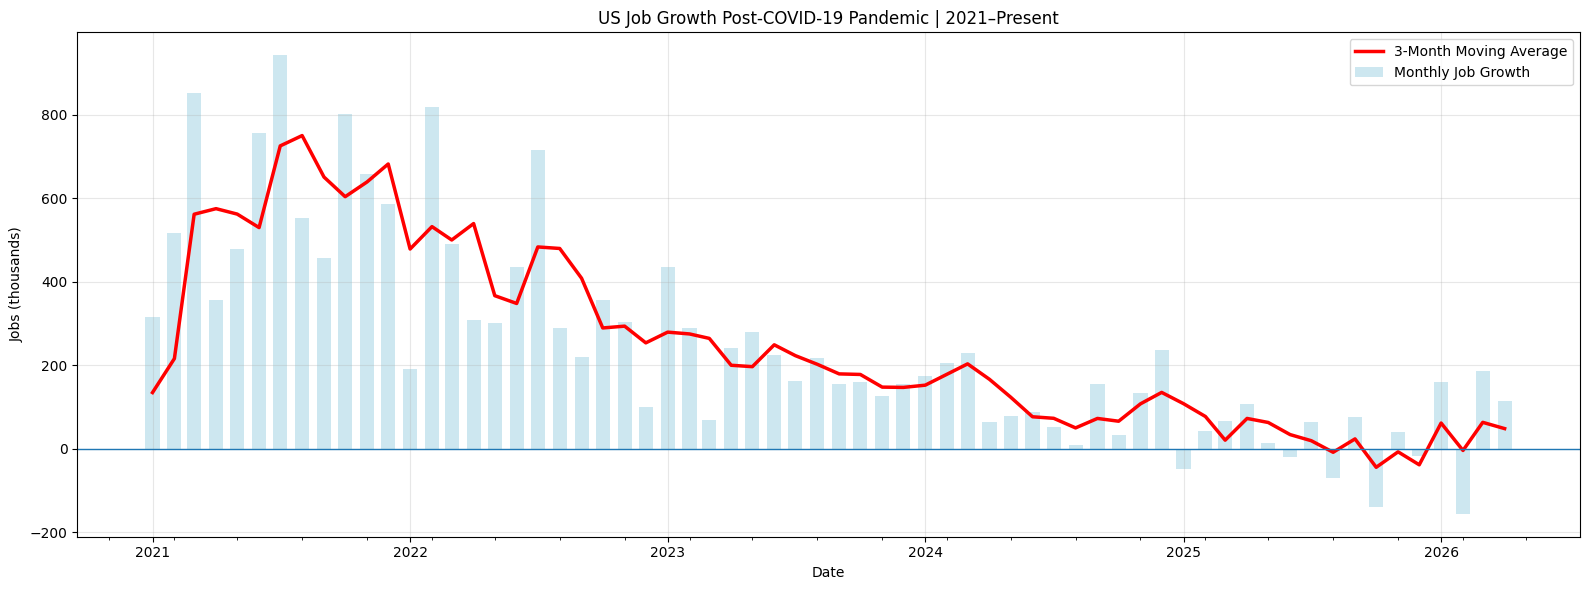

In [13]:
# 2021–Present | Post-COVID Recovery 
df_post = df[df.index >= "2021-01-01"]

plt.figure(figsize=(16, 6))

plt.bar(df_post.index, df_post["job_growth"], color="lightblue",width=20, alpha=0.6, label="Monthly Job Growth")
plt.plot(df_post.index, df_post["ma_3"], color="red", linewidth=2.5, label="3-Month Moving Average")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))

plt.axhline(0, linewidth=1)
plt.grid(alpha=0.3)

plt.title("US Job Growth Post-COVID-19 Pandemic | 2021–Present")
plt.ylabel("Jobs (thousands)")
plt.xlabel("Date")
plt.legend()

plt.tight_layout()
plt.show()

## Late-Cycle Behavior (2024–Present)

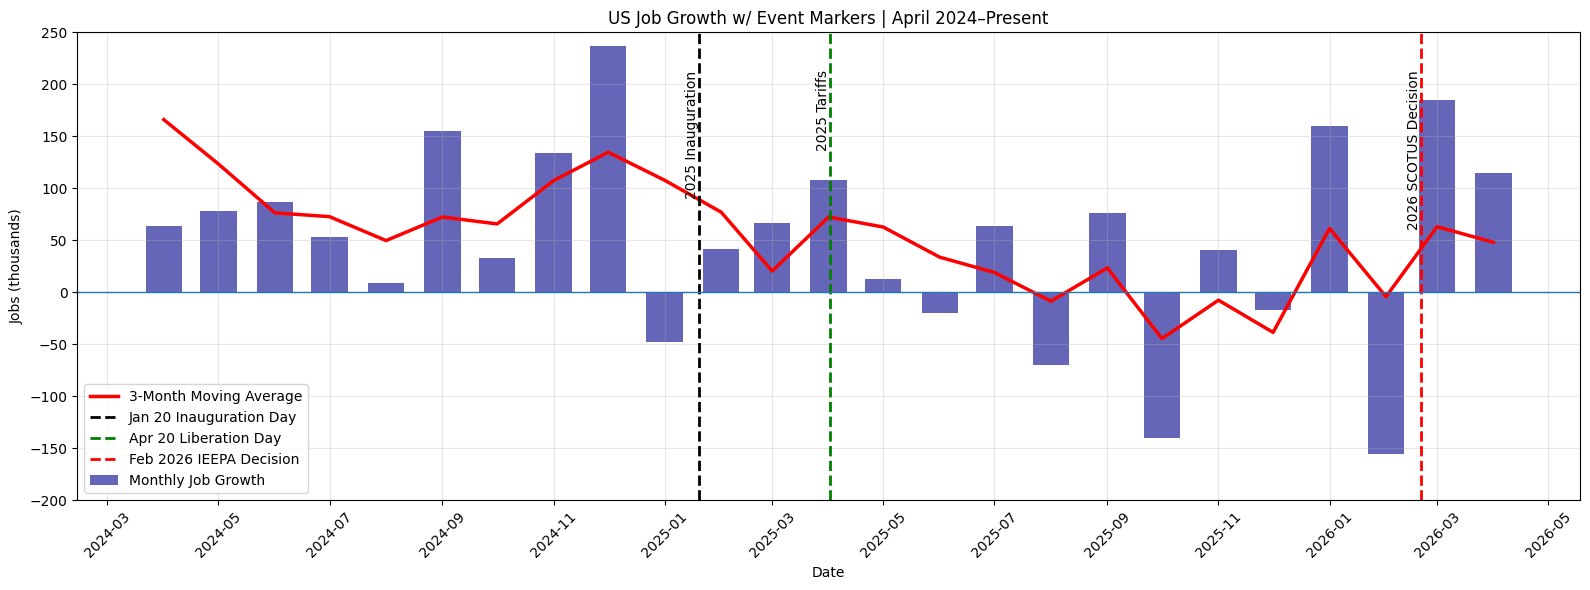

In [14]:
# Apr 2024 - Present : [Key dates:] 1/20/2025, 4/2/2025
df_focus = df[df.index >= "2024-04-01"]

plt.figure(figsize=(16, 6))

plt.bar(
    df_focus.index,
    df_focus["job_growth"],
    color="darkblue",
    width=20,
    alpha=0.6,
    label="Monthly Job Growth"
)

plt.plot(
    df_focus.index,
    df_focus["ma_3"],   
    color="red",
    linewidth=2.5,
    label="3-Month Moving Average"
)

# Key event markers
evt_20jan2025 = pd.to_datetime("2025-01-20")
evt_4apr2025 = pd.to_datetime("2025-04-02")
evt_20apr2026 = pd.to_datetime("2026-02-20")

plt.axvline(evt_20jan2025, color="black", linestyle="--", linewidth=2, label="Jan 20 Inauguration Day")
plt.axvline(evt_4apr2025, color="green", linestyle="--", linewidth=2, label="Apr 20 Liberation Day")
plt.axvline(evt_20apr2026, color="red", linestyle="--", linewidth=2, label="Feb 2026 IEEPA Decision")

# Labelss
y_max = df_focus["job_growth"].max()

plt.text(evt_20jan2025, y_max * 0.9, "2025 Inauguration", rotation=90, va='top', ha='right')
plt.text(evt_4apr2025, y_max * 0.9, "2025 Tariffs", rotation=90, va='top', ha='right')
plt.text(evt_20apr2026, y_max * 0.9, "2026 SCOTUS Decision", rotation=90, va='top', ha='right')

# Formatting
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.axhline(0, linewidth=1)
plt.ylim(-200, 250)

plt.grid(alpha=0.3)

plt.title("US Job Growth w/ Event Markers | April 2024–Present")
plt.ylabel("Jobs (thousands)")
plt.xlabel("Date")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()